<a href="https://www.kaggle.com/code/lalit7881/india-clinical-treatment-dataset?scriptVersionId=300914279" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ashyou09/indian-patient-disease-and-treatment-dataset/indian_diseases_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ashyou09/indian-patient-disease-and-treatment-dataset/indian_diseases_dataset.csv')

In [3]:
df.head()

,patient_id,age,age_group,gender,state,city,region,urban_rural,disease_name,disease_category,...,insurance_status,treatment_type,hospital_type,days_hospitalized,treatment_cost_inr,outcome,death_flag,cause_of_death,recovery_days,follow_up_required
0,IND-00000001,70,70-79,Female,Bihar,Patna,East,Semi-Urban,Diarrhea,Waterborne,...,Employer,Medication,Government,21,102.0,Recovering,0,NaN,42.0,Yes
1,IND-00000002,27,20-29,Other,Gujarat,Surat,West,Urban,Chikungunya,Vector-Borne,...,Uninsured,Medication,Government,0,1151.0,Recovered,0,NaN,18.0,Yes
2,IND-00000003,66,60-69,Other,Jharkhand,Bokaro,East,Rural,Hypertension,Non-Communicable,...,Private,Medication,Government,2,89.0,Chronic Management,0,NaN,NaN,Yes
3,IND-00000004,27,20-29,Female,Karnataka,Hubli,South,Rural,Tuberculosis,Infectious,...,Private,Surgery,Government,9,1269.0,Recovering,0,NaN,69.0,Yes
4,IND-00000005,40,40-49,Male,Karnataka,Belagavi,South,Rural,Chronic Kidney Disease,Non-Communicable,...,Ayushman Bharat,Palliative,Private,31,670576.0,Deceased,1,Complications from Chronic Kidney Disease,NaN,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          20000 non-null  object 
 1   age                 20000 non-null  int64  
 2   age_group           20000 non-null  object 
 3   gender              20000 non-null  object 
 4   state               20000 non-null  object 
 5   city                20000 non-null  object 
 6   region              20000 non-null  object 
 7   urban_rural         20000 non-null  object 
 8   disease_name        20000 non-null  object 
 9   disease_category    20000 non-null  object 
 10  severity            20000 non-null  object 
 11  diagnosis_date      20000 non-null  object 
 12  year                20000 non-null  int64  
 13  month               20000 non-null  object 
 14  season              20000 non-null  object 
 15  symptoms            20000 non-null  object 
 16  como

In [5]:
df.describe()

,age,year,bmi,days_hospitalized,treatment_cost_inr,death_flag,recovery_days
count,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,13693.000000
mean,44.061050,2021.498000,23.485495,9.771150,1.079405e+05,0.091100,33.205141
std,25.165393,2.294179,4.666045,12.078476,4.940645e+05,0.287758,26.427051
min,0.000000,2018.000000,14.000000,0.000000,1.200000e+01,0.000000,3.000000
25%,23.000000,2019.000000,19.700000,2.000000,1.421000e+03,0.000000,14.000000
50%,44.000000,2022.000000,23.200000,6.000000,6.604500e+03,0.000000,24.000000
75%,63.000000,2023.000000,27.000000,14.000000,3.933375e+04,0.000000,47.000000
max,95.000000,2025.000000,40.000000,60.000000,1.537582e+07,1.000000,100.000000


In [6]:
df.isnull().sum()

patient_id                0
age                       0
age_group                 0
gender                    0
state                     0
city                      0
region                    0
urban_rural               0
disease_name              0
disease_category          0
severity                  0
diagnosis_date            0
year                      0
month                     0
season                    0
symptoms                  0
comorbidity            6599
smoking_status            0
alcohol_use            6627
bmi                       0
blood_group               0
income_level              0
insurance_status          0
treatment_type            0
hospital_type             0
days_hospitalized         0
treatment_cost_inr        0
outcome                   0
death_flag                0
cause_of_death        18178
recovery_days          6307
follow_up_required        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(20000, 32)

In [9]:
df.dtypes

patient_id             object
age                     int64
age_group              object
gender                 object
state                  object
city                   object
region                 object
urban_rural            object
disease_name           object
disease_category       object
severity               object
diagnosis_date         object
year                    int64
month                  object
season                 object
symptoms               object
comorbidity            object
smoking_status         object
alcohol_use            object
bmi                   float64
blood_group            object
income_level           object
insurance_status       object
treatment_type         object
hospital_type          object
days_hospitalized       int64
treatment_cost_inr    float64
outcome                object
death_flag              int64
cause_of_death         object
recovery_days         float64
follow_up_required     object
dtype: object

In [10]:
df.columns

Index(['patient_id', 'age', 'age_group', 'gender', 'state', 'city', 'region',
       'urban_rural', 'disease_name', 'disease_category', 'severity',
       'diagnosis_date', 'year', 'month', 'season', 'symptoms', 'comorbidity',
       'smoking_status', 'alcohol_use', 'bmi', 'blood_group', 'income_level',
       'insurance_status', 'treatment_type', 'hospital_type',
       'days_hospitalized', 'treatment_cost_inr', 'outcome', 'death_flag',
       'cause_of_death', 'recovery_days', 'follow_up_required'],
      dtype='object')

In [11]:
df.nunique()

patient_id            20000
age                      96
age_group                 9
gender                    3
state                    33
city                    132
region                    6
urban_rural               3
disease_name             32
disease_category          7
severity                  4
diagnosis_date         2686
year                      8
month                    12
season                    4
symptoms              11245
comorbidity               6
smoking_status            3
alcohol_use               3
bmi                     261
blood_group               8
income_level              5
insurance_status          5
treatment_type            7
hospital_type             5
days_hospitalized        61
treatment_cost_inr    13884
outcome                   4
death_flag                2
cause_of_death           32
recovery_days            98
follow_up_required        2
dtype: int64

## EDA

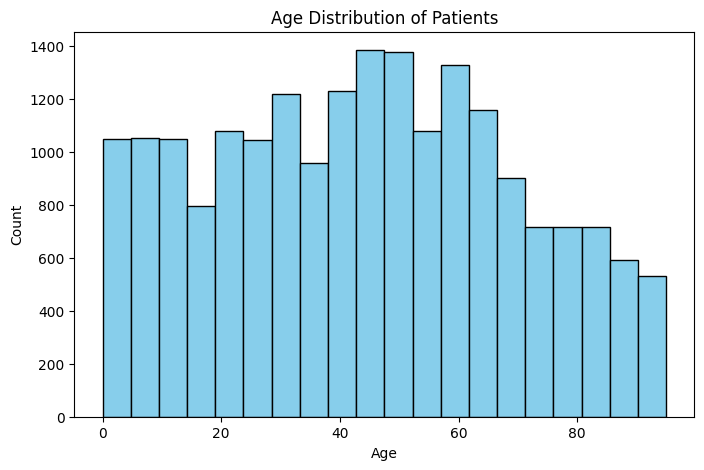

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

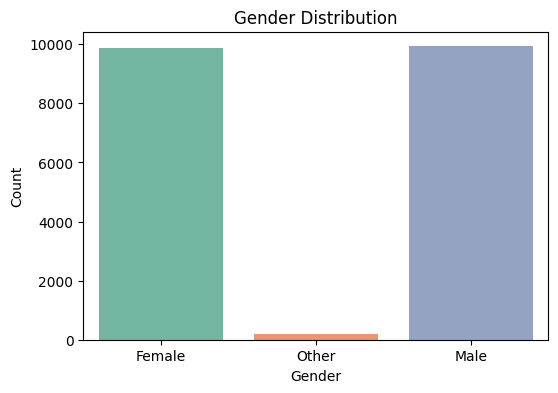

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


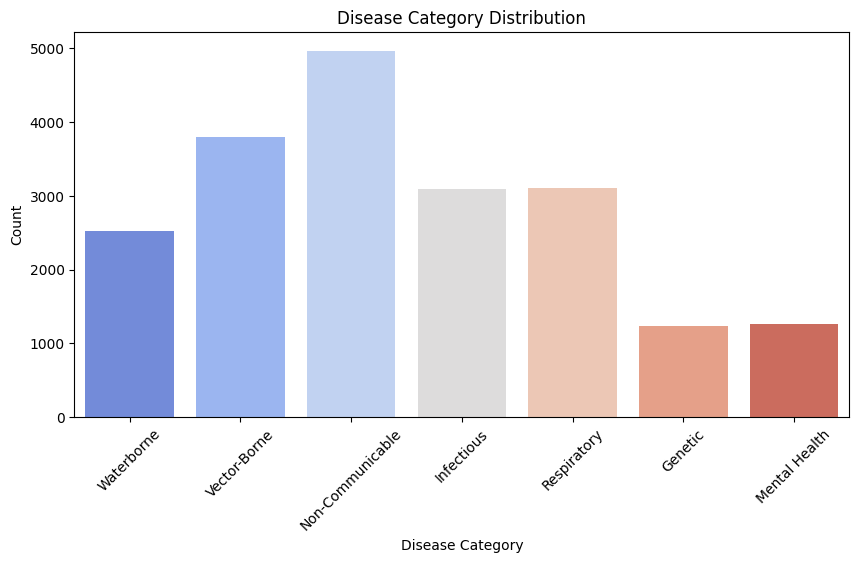

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='disease_category', data=df, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Disease Category Distribution')
plt.xlabel('Disease Category')
plt.ylabel('Count')
plt.show()

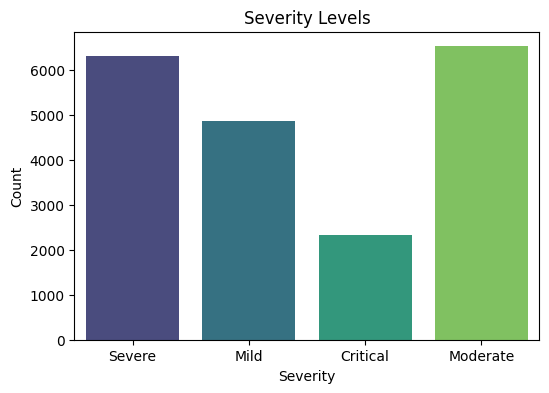

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='severity', data=df, palette='viridis')
plt.title('Severity Levels')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.show()

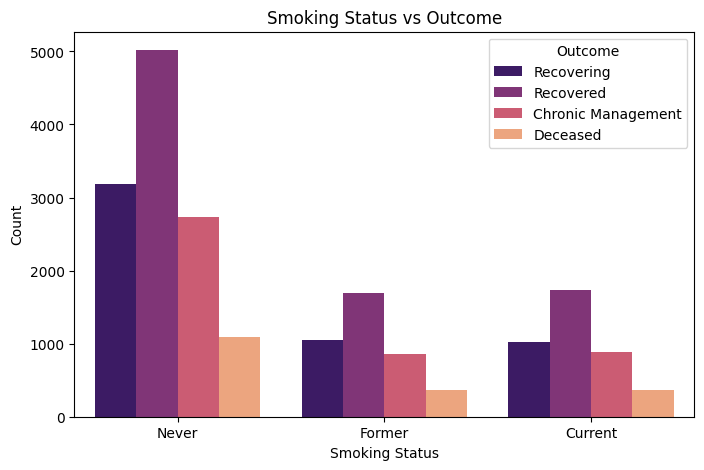

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='smoking_status', hue='outcome', data=df, palette='magma')
plt.title('Smoking Status vs Outcome')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.legend(title='Outcome')
plt.show()

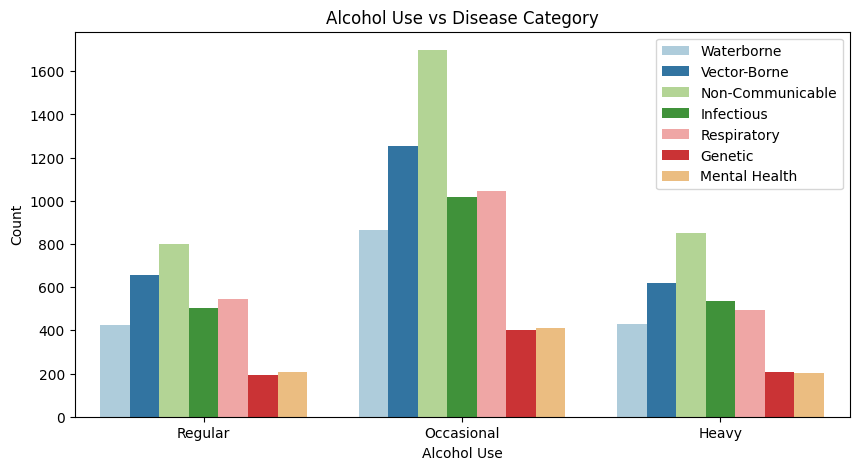

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x='alcohol_use', hue='disease_category', data=df, palette='Paired')
plt.title('Alcohol Use vs Disease Category')
plt.xlabel('Alcohol Use')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

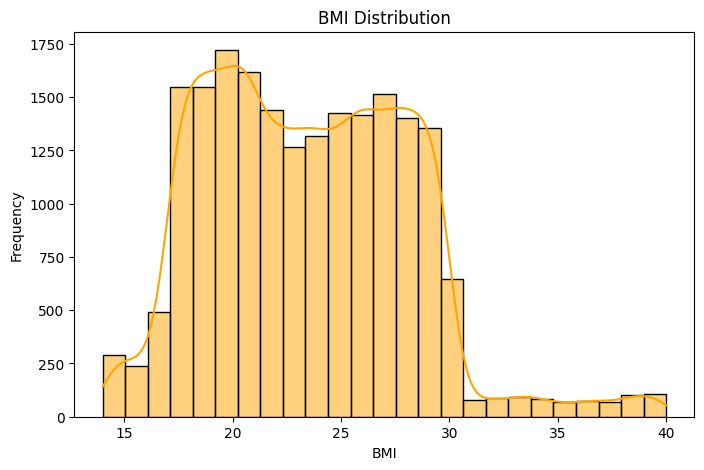

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=25, kde=True, color='orange')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

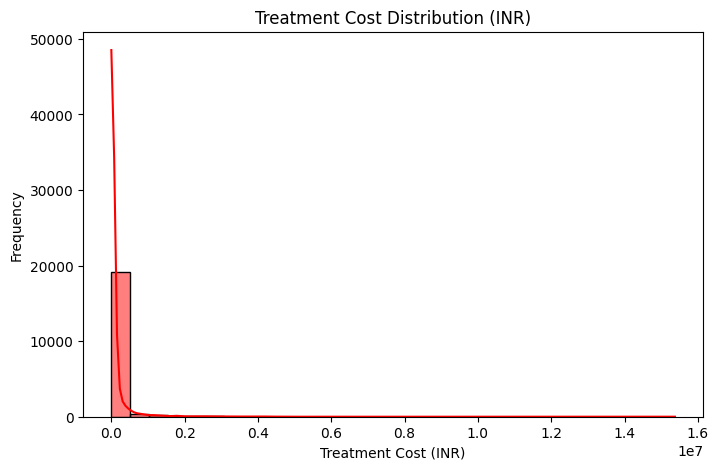

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['treatment_cost_inr'], bins=30, kde=True, color='red')
plt.title('Treatment Cost Distribution (INR)')
plt.xlabel('Treatment Cost (INR)')
plt.ylabel('Frequency')
plt.show()

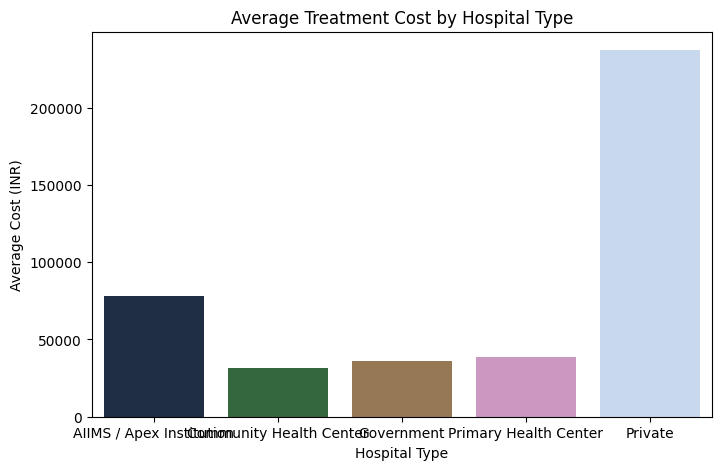

In [20]:
plt.figure(figsize=(8,5))
avg_cost = df.groupby('hospital_type')['treatment_cost_inr'].mean().reset_index()
sns.barplot(x='hospital_type', y='treatment_cost_inr', data=avg_cost, palette='cubehelix')
plt.title('Average Treatment Cost by Hospital Type')
plt.xlabel('Hospital Type')
plt.ylabel('Average Cost (INR)')
plt.show()

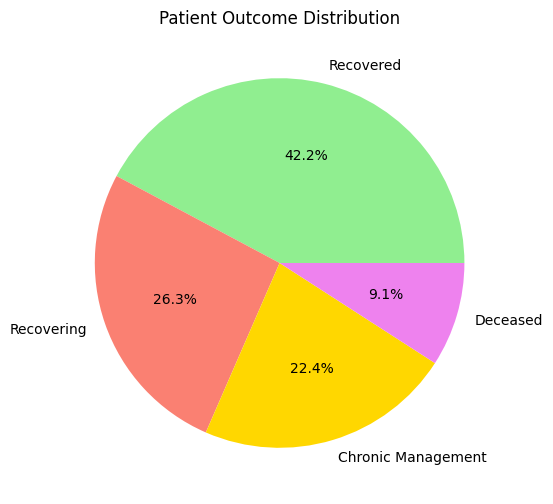

In [21]:
plt.figure(figsize=(6,6))
df['outcome'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['lightgreen','salmon','gold','violet']
)
plt.title('Patient Outcome Distribution')
plt.ylabel('')
plt.show()

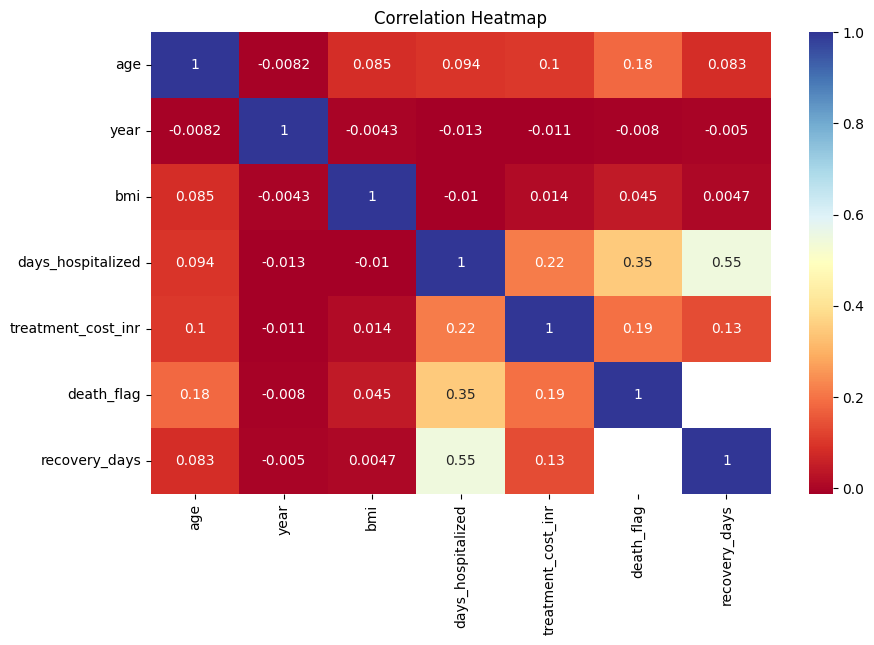

In [22]:
plt.figure(figsize=(10,6))
numeric_cols = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='RdYlBu')
plt.title('Correlation Heatmap')
plt.show()

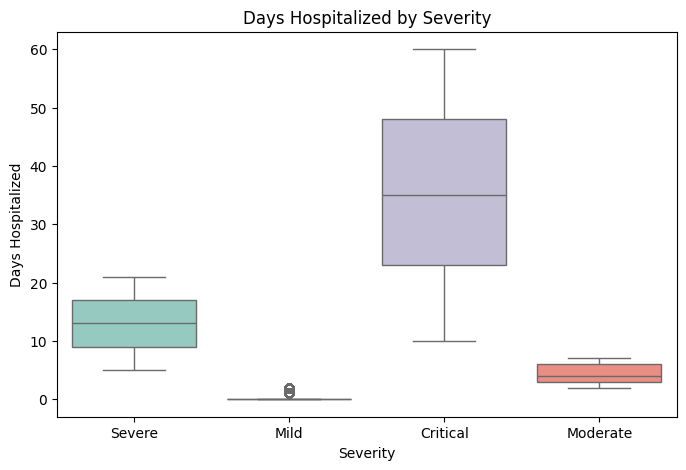

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='severity', y='days_hospitalized', data=df, palette='Set3')
plt.title('Days Hospitalized by Severity')
plt.xlabel('Severity')
plt.ylabel('Days Hospitalized')
plt.show()

## Feature engineering|

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [25]:
df = df.drop(columns=["cause_of_death"])

In [26]:
# Fill missing values
df["recovery_days"] = df["recovery_days"].fillna(0)
df["alcohol_use"] = df["alcohol_use"].fillna("Never")
df["comorbidity"] = df["comorbidity"].fillna("Unknown")

# Check null values
print(df.isnull().sum())

patient_id            0
age                   0
age_group             0
gender                0
state                 0
city                  0
region                0
urban_rural           0
disease_name          0
disease_category      0
severity              0
diagnosis_date        0
year                  0
month                 0
season                0
symptoms              0
comorbidity           0
smoking_status        0
alcohol_use           0
bmi                   0
blood_group           0
income_level          0
insurance_status      0
treatment_type        0
hospital_type         0
days_hospitalized     0
treatment_cost_inr    0
outcome               0
death_flag            0
recovery_days         0
follow_up_required    0
dtype: int64


In [27]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [28]:
X = df_encoded.drop("treatment_cost_inr", axis=1)
y = df_encoded["treatment_cost_inr"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# ⚡ Faster Random Forest
rf = RandomForestRegressor(
    n_estimators=50,       
    max_depth=10,           
    n_jobs=-1,              
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("===== Fast Random Forest Results =====")
print("R2 Score:", r2_score(y_test, rf_preds))
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

===== Fast Random Forest Results =====
R2 Score: 0.7419546367216018
MAE: 56049.042705575484
RMSE: 239943.04690357985


In [31]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

print("\n===== XGBoost Results =====")
print("R2 Score:", r2_score(y_test, xgb_preds))
print("MAE:", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))


===== XGBoost Results =====
R2 Score: 0.7004697003418282
MAE: 54134.23606346512
RMSE: 258511.88831520086


In [32]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "R2 Score": [
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ],
    "MAE": [
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_preds))
    ]
})

print(results)

           Model  R2 Score           MAE           RMSE
0  Random Forest  0.741955  56049.042706  239943.046904
1        XGBoost  0.700470  54134.236063  258511.888315


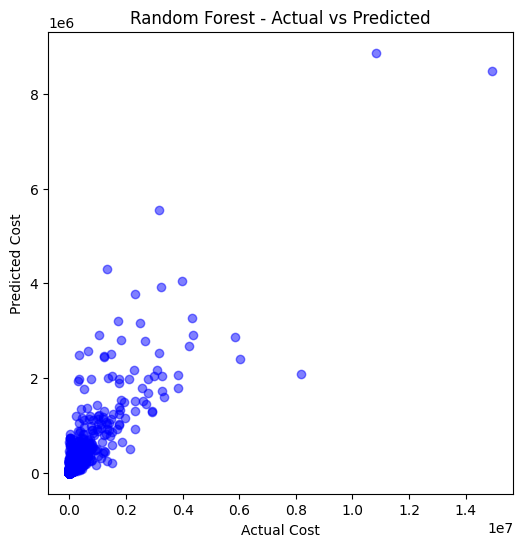

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_preds, color='blue', alpha=0.5)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Random Forest - Actual vs Predicted")
plt.show()

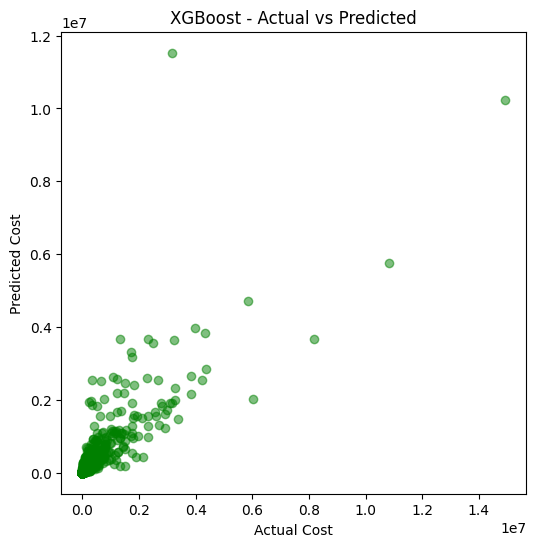

In [34]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_preds, color='green', alpha=0.5)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("XGBoost - Actual vs Predicted")
plt.show()

## Thank you..pls upvote!!!